In [1]:
root_dir = './' 
# please make sure the ref_adata and the query_adata are in the root_dir
objs = ['ST_ref_adata.h5ad---ST_query_adata.h5ad']
# ['{ref_adata1}---{query_adata1}','{ref_adata2}---{query_adata2}']

In [2]:
config_dict = {
    'annotation_mode':'st', # 'default','st'
    # st is for spatial data
    'identification_mode':'default', # 'default','csi'
    # csi is for cell subtype identification
    # when cell types in ref_adata may be different from those in query_adata, you can try 'csi'
    'run_mode':'cpu+gpu', # 'cpu+gpu','cpu_only'
    # when 'cpu_only', some frameworks can not work, the performance may be lower
    'framework_mode':'default', # 'default','rc_weighted'
    # when the result is not good enough, using 'rc_weighted' may be better 
    'save_dir':'./',
    'random_seeds':[42],
    'celltype_label':'celltype', 
    # when 'celltype_label' is 'xxx'
    # please make sure the celltype labels are in ref_adata.obs['xxx'] and query_adata.obs['xxx']
    # you can set query_adata.obs['celltype'] = 'not_clear'
    'celltype_filterlist':['Unknow','Unknown'],
    # in ref_adata and query_adata, remove cells which cell type labels are in the 'celltype_filterlist'
    'gpu_code':'0',
    # which gpu to use
}

In [3]:
with open('PCmaster_anno.v.0.0.2.py','r',encoding='utf-8') as f:
    exec(f.read())

pcma = PCmaster_anno_0()

2024-09-01 16:46:05
available_memory: 22.382503509521484 GB
used_memory: 9.473087310791016 GB
2024-09-01 16:46:06
available_memory: 22.376861572265625 GB
used_memory: 9.47866439819336 GB
2024-09-01 16:46:06
available_memory: 22.37497329711914 GB
used_memory: 9.48061752319336 GB


At the epoch 4, the model got the best valid accuracy 0.6907983761840325.
loss 0.005, train acc 0.999, valid acc 0.655
39168.1 examples/sec on cuda:0
memory used: 1.1901931762695312 GB
mapping_1_test,mapping_2_test
{'scutellum L1 epidermis': 0, 'scutellum L2 cortex': 1, 'radicle': 2, 'coleorhiza': 3, 'plumule': 4, 'coleoptile': 5, 'epiblast': 6, 'scutellum L3 vasculature': 7}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
mapping_1,mapping_2
{'scutellum L1 epidermis': 0, 'scutellum L2 cortex': 1, 'radicle': 2, 'coleorhiza': 3, 'coleoptile': 4, 'plumule': 5, 'epiblast': 6, 'scutellum L3 vasculature': 7}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
./ST_ref_adata.h5ad
./ST_query_adata.h5ad
test_label_unmapped
scutellum L1 epidermis
scutellum L2 cortex
scutellum L2 cortex
scutellum L2 cortex
scutellum L2 cortex
scutellum L1 epidermis
scutellum L1 epidermis
scutellum L2 cortex
scutellum L2 cortex
scutellum L2 cortex
predicted_unmapped
radicle
radicle
scutellum L2 cortex
radicle
scute

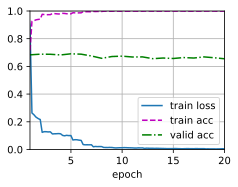

In [4]:
pcma_annotation_mygo(config_dict = config_dict)

In [5]:
save_dir = config_dict['save_dir']
obj = objs[0]
random_seed = config_dict['random_seeds'][0]

with open(save_dir+'test_label_'+str(obj)+'_'+str(random_seed)+'.pkl','rb') as file:
    test_label_unmapped = pickle.load(file)
with open(save_dir+'predicted_'+str(obj)+'_'+str(random_seed)+'.pkl','rb') as file:
    predicted_unmapped = pickle.load(file)
with open(save_dir+'ref_mapping_'+str(obj)+'_'+str(random_seed)+'.pkl','rb') as file:
    ref_mapping = pickle.load(file)

In [6]:
scobj = sc.read(root_dir+objs[0].split('---')[1])

print(len(scobj.obs_names))
print(len(test_label_unmapped))

scobj.obs['Prediction'] = predicted_unmapped

scobj = scobj[scobj.obs[config_dict['celltype_label']].isin(ref_mapping.keys())]

2670
2670


C:\Users\86135\AppData\Local\Temp\ipykernel_5272\2711853443.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  scobj.obs['query - true labels'] = scobj.obs['celltype']


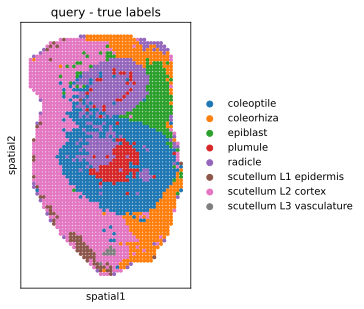

In [7]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
scobj.obs['query - true labels'] = scobj.obs['celltype']
sc.pl.spatial(scobj, img_key="hires", color=['query - true labels'],spot_size = 60)

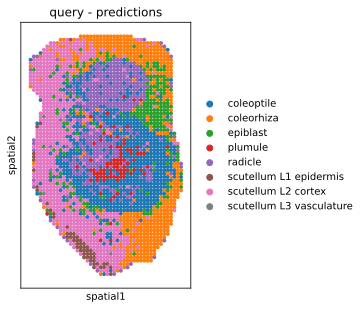

In [8]:
scobj.obs['query - predictions'] = predicted_unmapped
sc.pl.spatial(scobj, img_key="hires", color=['query - predictions'],spot_size = 60)